# 06 — Credit policy simulator: cutoffs and limits

Notebook 04 built a default score. A score only earns its keep when it changes a
decision, and a lender makes two: **whether** to approve an applicant, and **how
much** to lend them. This notebook replays both decisions on the 2015–2016 book
and sizes what each one does to approvals, exposure and loss.

* **Part A — score cutoffs.** Approve only the lowest-risk X% of applicants.
* **Part B — limit assignment.** Approve everyone, but fund the riskier ones at
  a fraction of the amount they asked for.
* **Part C — both together**, and a recommendation.

### The rules this simulation follows

1. **Out of time.** Every loan is scored by notebook 04's logistic model, which
   was fit on 2007–2014 vintages and never saw these loans.
2. **Resolved and matured loans only.** The book is the 333,721 loans in notebook
   04's test set: 36-month loans issued January 2015 to February 2016, all with a
   terminal status (Fully Paid or Charged Off), FICO 660+. Their full term had run
   by the March 2019 snapshot, so no outcome is still developing. The 60-month
   loans from these years had not matured and are excluded, so this is a
   36-month book.
3. **Bad** = status Charged Off, Default, or "Does not meet the credit policy.
   Status:Charged Off".
4. **Realized loss** = funded amount − principal repaid − recoveries, floored at
   zero. **Loss rate** = realized loss ÷ funded amount, in basis points.
   **Exposure** = funded amount.
5. **Tightening only.** Declined applicants never got a loan, so their outcomes are
   unknown (no reject inference). The simulator can show what declining or
   shrinking booked loans would have done. It cannot show what approving more
   people would do.

In [1]:
import logging
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

from src import data_prep as dp  # noqa: E402
from src import plotting as pl  # noqa: E402
from src import policy as pol  # noqa: E402

pl.set_style()
# DejaVu Sans has no semibold cut; matplotlib falls back to bold and says so on every run.
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

book = pol.load_policy_book()
base = pol.cutoff_sweep(book, [1.0]).iloc[0]

print(f"Holdout book:   {len(book):,} loans, issued {book['issue_d'].min():%b %Y} – {book['issue_d'].max():%b %Y}")
print(f"Term:           {sorted(book['term_months'].astype(int).unique().tolist())} months")
print(f"Statuses:       {book['loan_status'].value_counts().to_dict()}")
print(f"Exposure:       ${base['Exposure ($M)'] / 1e3:.3f}B")
print(f"Bad rate:       {base['Bad rate']:.3%}")
print(f"Realized loss:  ${base['Loss ($M)']:.1f}M  ->  {base['Loss rate (bps)']:.0f} bps of exposure")

Holdout book:   333,721 loans, issued Jan 2015 – Feb 2016
Term:           [36] months
Statuses:       {'Fully Paid': 284067, 'Charged Off': 49654}
Exposure:       $4.320B
Bad rate:       14.879%
Realized loss:  $322.0M  ->  745 bps of exposure


## Quality checks before any policy

Four things have to hold before the simulation means anything.

In [2]:
# 1. The baseline matches what notebooks 04 and 05 already published for this book.
published = {"Bad rate": 0.14879, "Exposure ($B)": 4.320, "Realized loss ($M)": 322.0, "Loss rate": 0.0745}
reproduced = {"Bad rate": base["Bad rate"], "Exposure ($B)": base["Exposure ($M)"] / 1e3,
              "Realized loss ($M)": base["Loss ($M)"], "Loss rate": base["Loss rate (bps)"] / 1e4}
check_1 = pd.DataFrame({"Notebook 05": published, "This notebook": reproduced})
print("1. Baseline vs notebook 05")
print(check_1.round(5).to_string(), "\n")

# The loss formula above and notebook 01's net charge-off are the same quantity.
gap = (book["realized_loss"] - book["net_chargeoff"]).abs()
print(f"   Realized loss vs notebook 01 net charge-off: total gap ${gap.sum():,.0f}, "
      f"largest single-loan gap ${gap.max():,.2f}")
print(f"   Bad flag (rule 3) vs notebook 01 charged_off: identical = {(book['bad'] == book['charged_off']).all()}")
print("   'Does not meet the credit policy' loans in this book: "
      f"{book['loan_status'].str.startswith('Does not meet').sum()} (they are all 2007–2010 vintages)\n")

# 2. Holdout vintages are disjoint from training vintages.
clean = pd.read_parquet(dp.PROCESSED)
train = clean[(clean["fico_band"] != "<660") & (clean["vintage_year"] <= pol.TRAIN_THROUGH)]
print("2. Train and holdout windows")
print(f"   Train:   {len(train):,} loans issued {train['issue_d'].min():%Y-%m} to {train['issue_d'].max():%Y-%m}")
print(f"   Holdout: {len(book):,} loans issued {book['issue_d'].min():%Y-%m} to {book['issue_d'].max():%Y-%m}")
print(f"   Overlap in issue months: {len(set(train['issue_d']) & set(book['issue_d']))}\n")

# 3. No post-origination field is a model input.
model_inputs = set(dp.NUMERIC_FEATURES + dp.CATEGORICAL_FEATURES)
outcome_fields = {"total_rec_prncp", "recoveries", "total_rec_int", "last_pymnt_d", "total_pymnt"}
print("3. Leakage")
print(f"   Model inputs on the leakage list:     {sorted(model_inputs & set(dp.LEAKAGE)) or 'none'}")
print(f"   Outcome fields used as model inputs:  {sorted(model_inputs & outcome_fields) or 'none'}")
print(f"   Outcome fields all on the leakage list: {outcome_fields <= set(dp.LEAKAGE)}")

1. Baseline vs notebook 05
                    Notebook 05  This notebook
Bad rate                0.14879        0.14879
Exposure ($B)           4.32000        4.32016
Realized loss ($M)    322.00000      322.02552
Loss rate               0.07450        0.07454 

   Realized loss vs notebook 01 net charge-off: total gap $8, largest single-loan gap $2.00
   Bad flag (rule 3) vs notebook 01 charged_off: identical = True
   'Does not meet the credit policy' loans in this book: 0 (they are all 2007–2010 vintages)

2. Train and holdout windows
   Train:   398,906 loans issued 2007-06 to 2014-12
   Holdout: 333,721 loans issued 2015-01 to 2016-02


   Overlap in issue months: 0

3. Leakage
   Model inputs on the leakage list:     none
   Outcome fields used as model inputs:  none
   Outcome fields all on the leakage list: True


Check 4, that the loss rate falls as the cutoff tightens, is run right after the
sweep below.

## Part A — Score cutoffs

Rank the book by predicted default probability and approve only the safest X%.
The sweep runs from approving everyone down to approving half.

In [3]:
sweep = pol.cutoff_sweep(book)

# 4. Loss rate falls at every step.
steps = sweep["Loss rate (bps)"].diff().dropna()
print(f"4. Loss rate falls at every 5-point step: {(steps < 0).all()} "
      f"(smallest drop {-steps.max():.1f} bps, largest {-steps.min():.1f} bps)\n")

show = sweep[["Loans", "PD cutoff", "Bad rate", "Loss rate (bps)", "Exposure ($M)", "Loss ($M)",
              "Δ approvals", "Δ loss rate (bps)", "Δ exposure", "Δ loss $"]].copy()
show.index = show.index.map("{:.0%}".format)
show.style.format({
    "Loans": "{:,.0f}", "PD cutoff": "{:.3f}", "Bad rate": "{:.2%}", "Loss rate (bps)": "{:.0f}",
    "Exposure ($M)": "{:,.0f}", "Loss ($M)": "{:,.1f}", "Δ approvals": "{:+.0%}",
    "Δ loss rate (bps)": "{:+.0f}", "Δ exposure": "{:+.1%}", "Δ loss $": "{:+.1%}",
})

4. Loss rate falls at every 5-point step: True (smallest drop 24.8 bps, largest 43.2 bps)



,Loans,PD cutoff,Bad rate,Loss rate (bps),Exposure ($M),Loss ($M),Δ approvals,Δ loss rate (bps),Δ exposure,Δ loss $
Approval rate,,,,,,,,,,
100%,"333,721",1.000,14.88%,745,"4,320",322.0,+0%,+0,+0.0%,+0.0%
95%,"317,035",0.246,14.05%,702,"4,144",291.0,-5%,-43,-4.1%,-9.6%
90%,"300,349",0.216,13.37%,665,"3,952",262.7,-10%,-81,-8.5%,-18.4%
85%,"283,663",0.196,12.78%,632,"3,752",237.1,-15%,-113,-13.2%,-26.4%
80%,"266,977",0.182,12.25%,603,"3,548",213.8,-20%,-143,-17.9%,-33.6%
75%,"250,291",0.170,11.69%,574,"3,343",191.7,-25%,-172,-22.6%,-40.5%
70%,"233,605",0.159,11.17%,545,"3,132",170.7,-30%,-201,-27.5%,-47.0%
65%,"216,919",0.150,10.66%,516,"2,921",150.8,-35%,-229,-32.4%,-53.2%
60%,"200,233",0.141,10.17%,488,"2,711",132.4,-40%,-257,-37.3%,-58.9%


**The score works as a cutoff tool.** Declining the riskiest 10% of the book takes
the loss rate from 745 to 665 bps and cuts loss dollars by 18%, for an 8.5%
reduction in exposure. Loss dollars fall faster than exposure at every step, and
about twice as fast over the first 15 points, which is what rank-ordering buys:
the loans being turned away are much worse than the ones being kept.

"PD cutoff" is the model probability of the riskiest loan still approved. Notebook
04 showed the model under-predicts this book's level by about 12%, so the cutoff is
better stated as an approval rate than as a PD.

### Were the declined loans worth keeping?

The average loss rate of what's left is only half the question. The other half is
what each slice being declined actually earned. The table below values every
5-point slice on its own: realized loss, and interest actually received over the
loan's life.

In [4]:
slices = pol.marginal_slices(book)
slices[["Loans", "Avg coupon", "Bad rate", "Loss rate (bps)", "Interest ($M)", "Loss ($M)",
        "Net of loss (bps)"]].style.format({
    "Loans": "{:,.0f}", "Avg coupon": "{:.1%}", "Bad rate": "{:.1%}", "Loss rate (bps)": "{:,.0f}",
    "Interest ($M)": "{:.1f}", "Loss ($M)": "{:.1f}", "Net of loss (bps)": "{:+,.0f}",
})

,Loans,Avg coupon,Bad rate,Loss rate (bps),Interest ($M),Loss ($M),Net of loss (bps)
Declined slice,,,,,,,
95%–100%,"16,686",16.0%,30.6%,"1,761",35.2,31.0,+235
90%–95%,"16,686",14.6%,26.4%,"1,474",35.0,28.3,+352
85%–90%,"16,686",13.9%,23.3%,"1,279",34.8,25.6,+458
80%–85%,"16,686",13.4%,21.3%,"1,143",34.5,23.3,+549
75%–80%,"16,686",13.0%,20.6%,"1,074",33.7,22.1,+566
70%–75%,"16,686",12.6%,19.0%,"1,002",33.2,21.1,+578
65%–70%,"16,686",12.3%,17.8%,942,32.6,19.9,+600
60%–65%,"16,686",12.0%,16.6%,873,31.7,18.4,+632
55%–60%,"16,686",11.7%,15.6%,807,31.2,17.2,+656


**Every slice still earned more interest than it lost, including the worst 5%.**
The riskiest 5% of loans lost 1,761 bps of principal but paid 1,996 bps of
interest, leaving +235 bps over the life of the loan. The book as a whole netted
+640 bps. That is before LendingClub's servicing fee and before any cost of funds,
both of which would eat into that thin margin.

So a cutoff does not remove money-losing loans outright. It removes the
thinnest-margin, most volatile part of the book. That is a defensible trade, but it
is a trade, and it shows up below as lower interest income.

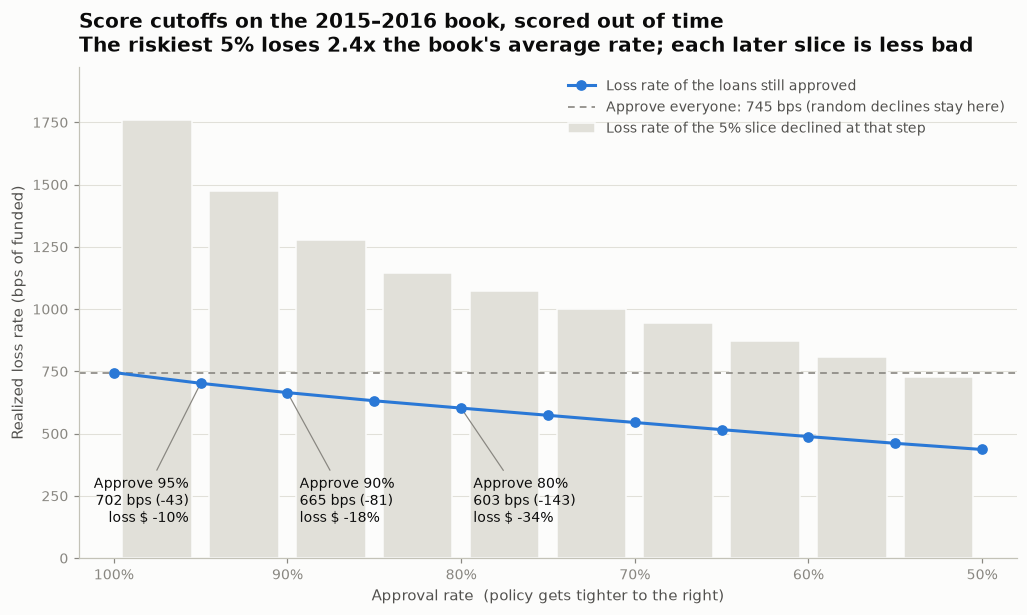

In [5]:
fig, ax = plt.subplots(figsize=(11, 5.8))

rates = sweep.index.values
loss_bps = sweep["Loss rate (bps)"].values

# Light bars: the loss rate of the 5-point slice each step declines, centred on it.
centres = rates[:-1] - 0.025
ax.bar(centres, slices["Loss rate (bps)"].values, width=0.04, color=pl.GRIDLINE,
       edgecolor=pl.SURFACE, label="Loss rate of the 5% slice declined at that step")
ax.plot(rates, loss_bps, color=pl.CATEGORICAL[0], marker="o", markersize=6, zorder=5,
        label="Loss rate of the loans still approved")
ax.axhline(loss_bps[0], color=pl.INK_MUTED, linewidth=1.1, linestyle=(0, (4, 3)),
           label=f"Approve everyone: {loss_bps[0]:.0f} bps (random declines stay here)")

# Labels sit on one row below the curve; alignment alternates so neighbours don't collide.
for rate, x_text, align in [(0.95, 0.957, "right"), (0.90, 0.893, "left"), (0.80, 0.793, "left")]:
    row = sweep.loc[rate]
    ax.annotate(
        f"Approve {rate:.0%}\n{row['Loss rate (bps)']:.0f} bps ({row['Δ loss rate (bps)']:+.0f})\n"
        f"loss $ {row['Δ loss $']:+.0%}",
        xy=(rate, row["Loss rate (bps)"]), xytext=(x_text, 330),
        ha=align, va="top", fontsize=9, color=pl.INK_PRIMARY,
        arrowprops=dict(arrowstyle="-", color=pl.INK_MUTED, lw=0.8),
    )

ax.set_xlim(1.02, 0.48)
ax.set_ylim(0, slices["Loss rate (bps)"].max() * 1.12)
pl.pct_axis(ax, "x", decimals=0)
ax.set_xlabel("Approval rate  (policy gets tighter to the right)")
ax.set_ylabel("Realized loss rate (bps of funded)")
ax.set_title(
    "Score cutoffs on the 2015–2016 book, scored out of time\n"
    "The riskiest 5% loses 2.4x the book's average rate; each later slice is less bad",
    loc="left",
)
pl.style_axes(ax)
ax.legend(loc="upper right")

pl.save_fig(fig, "06_cutoff_tradeoff.png")
plt.show()

## Part B — Limit assignment

LendingClub funded what borrowers asked for. A lender with a limit policy would
instead offer riskier applicants a smaller loan. Here the book is split into PD
quintiles (band 1 = safest) and each band is funded at a fixed share of the
requested amount.

**Assumption:** a capped loan defaults exactly when the full loan did, and its
loss and interest shrink in proportion to its size. A smaller payment might in
fact lower the default rate, and some borrowers would turn down a smaller offer.
Neither effect is modeled, so these numbers size the mechanical effect of
smaller balances only.

In [6]:
bands = pol.pd_bands(book)
band_view = book.assign(band=bands).groupby("band").agg(
    Loans=("bad", "size"), PD_range=("pd_pred", lambda s: f"{s.min():.3f}–{s.max():.3f}"),
    Bad_rate=("bad", "mean"), Avg_size=("exposure", "mean"),
    Exposure=("exposure", "sum"), Loss=("realized_loss", "sum"), Interest=("interest_received", "sum"),
)
band_view["Share of exposure"] = band_view["Exposure"] / band_view["Exposure"].sum()
band_view["Loss rate (bps)"] = band_view["Loss"] / band_view["Exposure"] * 1e4
band_view["Net of loss (bps)"] = (band_view["Interest"] - band_view["Loss"]) / band_view["Exposure"] * 1e4
band_view[["Loans", "PD_range", "Bad_rate", "Avg_size", "Share of exposure", "Loss rate (bps)",
           "Net of loss (bps)"]].style.format({
    "Loans": "{:,.0f}", "Bad_rate": "{:.1%}", "Avg_size": "${:,.0f}", "Share of exposure": "{:.1%}",
    "Loss rate (bps)": "{:,.0f}", "Net of loss (bps)": "{:+,.0f}",
})

,Loans,PD_range,Bad_rate,Avg_size,Share of exposure,Loss rate (bps),Net of loss (bps)
band,,,,,,,
1,"66,745",0.000–0.079,5.9%,"$14,346",22.2%,272,+735
2,"66,744",0.079–0.110,10.5%,"$13,384",20.7%,511,+731
3,"66,744",0.110–0.141,14.2%,"$12,882",19.9%,706,+696
4,"66,744",0.141–0.182,18.5%,"$12,550",19.4%,972,+594
5,"66,744",0.182–1.000,25.4%,"$11,565",17.9%,"1,402",+405


The worst band loses five times as much per dollar as the best (1,402 vs 272 bps)
and holds 17.9% of the exposure. Three schedules for shrinking it:

In [7]:
SCHEDULES = {
    "Worst band only": [1.00, 1.00, 1.00, 1.00, 0.60],
    "Graduated":       [1.00, 0.95, 0.85, 0.70, 0.60],
    "Steep":           [1.00, 0.90, 0.75, 0.60, 0.50],
}
limits = pol.limit_comparison(book, SCHEDULES)
limits.style.format({
    "Exposure ($M)": "{:,.0f}", "Δ exposure": "{:+.1%}", "Δ loss $": "{:+.1%}",
    "Loss rate (bps)": "{:.0f}", "Δ loss rate (bps)": "{:+.0f}", "Worst-band share before": "{:.1%}",
    "Worst-band share after": "{:.1%}", "Δ interest": "{:+.1%}",
})

,"Caps, best → worst band",Exposure ($M),Δ exposure,Δ loss $,Loss rate (bps),Δ loss rate (bps),Worst-band share before,Worst-band share after,Δ interest
Schedule,,,,,,,,,
Worst band only,100% / 100% / 100% / 100% / 60%,"4,011",-7.1%,-13.4%,695,-51,17.9%,11.5%,-9.3%
Graduated,100% / 95% / 85% / 70% / 60%,"3,586",-17.0%,-24.6%,677,-68,17.9%,12.9%,-19.8%
Steep,100% / 90% / 75% / 60% / 50%,"3,295",-23.7%,-33.0%,654,-91,17.9%,11.7%,-27.3%


**Limits lower the loss rate without declining anyone, but they are a blunter
tool than a cutoff.** Capping only the worst band at 60% cuts the loss rate by
51 bps and loss dollars by 13%, for 7.1% less exposure. A cutoff that removes
8.5% of exposure (approve 90%) cuts the loss rate by 81 bps.

The reason is that a cap shrinks every loan in a band equally, including the
better loans near the band's edge, while a cutoff removes only the very worst.
Measured per dollar of exposure given up, cutoffs win. Measured per customer
turned away, limits win, because they turn nobody away.

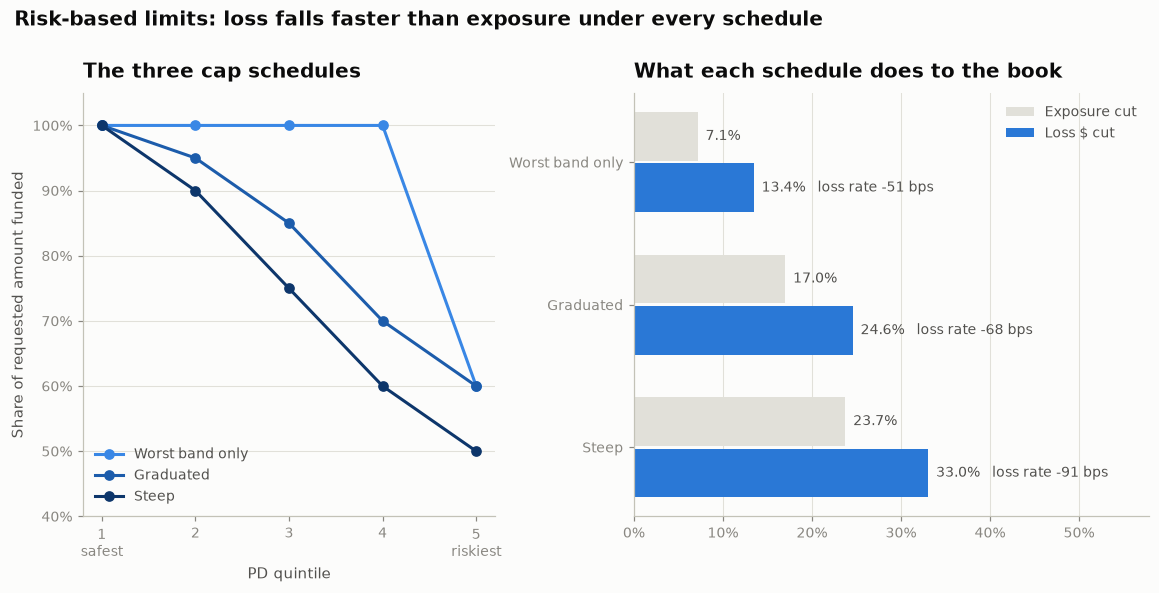

In [8]:
fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(12.5, 5), gridspec_kw={"width_ratios": [1, 1.25], "wspace": 0.3})
colors = [pl.BLUE_RAMP[2], pl.BLUE_RAMP[5], pl.BLUE_RAMP[8]]

for (name, caps), color in zip(SCHEDULES.items(), colors):
    ax_l.plot(range(1, 6), caps, color=color, marker="o", markersize=6, label=name)
ax_l.set_xticks(range(1, 6))
ax_l.set_xticklabels(["1\nsafest", "2", "3", "4", "5\nriskiest"])
ax_l.set_ylim(0.4, 1.05)
pl.pct_axis(ax_l, decimals=0)
ax_l.set_xlabel("PD quintile")
ax_l.set_ylabel("Share of requested amount funded")
ax_l.set_title("The three cap schedules", loc="left")
ax_l.legend(loc="lower left")
pl.style_axes(ax_l)

y = np.arange(len(limits))
ax_r.barh(y - 0.18, -limits["Δ exposure"], height=0.34, color=pl.GRIDLINE, label="Exposure cut")
ax_r.barh(y + 0.18, -limits["Δ loss $"], height=0.34, color=pl.CATEGORICAL[0], label="Loss $ cut")
for yi, (_, row) in enumerate(limits.iterrows()):
    ax_r.text(-row["Δ exposure"], yi - 0.18, f"  {-row['Δ exposure']:.1%}", va="center", fontsize=9,
              color=pl.INK_SECONDARY)
    ax_r.text(-row["Δ loss $"], yi + 0.18, f"  {-row['Δ loss $']:.1%}   loss rate {row['Δ loss rate (bps)']:+.0f} bps",
              va="center", fontsize=9, color=pl.INK_SECONDARY)
ax_r.set_yticks(y, limits.index)
ax_r.invert_yaxis()
ax_r.set_xlim(0, -limits["Δ loss $"].min() * 1.75)
pl.pct_axis(ax_r, "x", decimals=0)
ax_r.set_title("What each schedule does to the book", loc="left")
ax_r.legend(loc="upper right")
ax_r.grid(axis="y", visible=False)
ax_r.grid(axis="x", visible=True)

fig.suptitle("Risk-based limits: loss falls faster than exposure under every schedule",
             x=0.075, ha="left", fontsize=13, fontweight="semibold", color=pl.INK_PRIMARY, y=1.03)
pl.save_fig(fig, "06_limit_schedules.png")
plt.show()

## Part C — Cutoff and limits together

Three candidate policies, against the approve-everyone baseline. A cutoff-only
policy is included as a reference point. The PD bands are fixed on the full book,
so a cutoff removes loans from the top band before any cap applies.

In [9]:
POLICIES = {
    "Reference: cutoff only": (0.90, [1.00, 1.00, 1.00, 1.00, 1.00]),
    "A. Light":    (0.95, SCHEDULES["Worst band only"]),
    "B. Balanced": (0.90, SCHEDULES["Graduated"]),
    "C. Tight":    (0.80, SCHEDULES["Steep"]),
}
summary = pd.DataFrame({name: pol.evaluate_policy(book, rate, caps) for name, (rate, caps) in POLICIES.items()}).T
baseline_row = pol.evaluate_policy(book, 1.0, [1.0] * 5)
summary = pd.concat([pd.DataFrame({"Approve everyone": baseline_row}).T, summary])
summary[["Approval rate", "Caps, best → worst band", "Exposure ($M)", "Loss ($M)", "Loss rate (bps)",
         "Δ approvals", "Δ exposure", "Δ loss rate (bps)", "Δ loss $", "Δ net of loss $"]].style.format({
    "Approval rate": "{:.0%}", "Exposure ($M)": "{:,.0f}", "Loss ($M)": "{:,.1f}", "Loss rate (bps)": "{:.0f}",
    "Δ approvals": "{:+.0%}", "Δ exposure": "{:+.1%}", "Δ loss rate (bps)": "{:+.0f}", "Δ loss $": "{:+.1%}",
    "Δ net of loss $": "{:+.1%}",
})

,Approval rate,"Caps, best → worst band",Exposure ($M),Loss ($M),Loss rate (bps),Δ approvals,Δ exposure,Δ loss rate (bps),Δ loss $,Δ net of loss $
Approve everyone,100%,100% / 100% / 100% / 100% / 100%,"4,320",322.0,745,+0%,+0.0%,+0,+0.0%,+0.0%
Reference: cutoff only,90%,100% / 100% / 100% / 100% / 100%,"3,952",262.7,665,-10%,-8.5%,-81,-18.4%,-3.9%
A. Light,95%,100% / 100% / 100% / 100% / 60%,"3,906",260.1,666,-5%,-9.6%,-79,-19.2%,-5.4%
B. Balanced,90%,100% / 95% / 85% / 70% / 60%,"3,366",207.3,616,-10%,-22.1%,-129,-35.6%,-16.7%
C. Tight,80%,100% / 90% / 75% / 60% / 50%,"2,909",161.5,555,-20%,-32.7%,-190,-49.8%,-26.3%


### Recommendation: Policy A

Approve the safest 95% of applicants and fund the riskiest fifth at 60% of the
amount they asked for. That takes the loss rate from 745 to 666 bps, the same
improvement as declining 10% of applicants (665 bps), while turning away half as
many people and keeping 90% of exposure. The cutoff-only route gives up slightly
less margin (3.9% of interest net of losses, against 5.4% for A), but for a lender
that is still growing, keeping about 16,700 more customers is worth those 1.5
points. B and C cut losses further, but each basis point of improvement costs about
twice as much margin as it does under A.

## Limitations

* **No reject inference.** Only booked loans have outcomes, so these results size
  tightening. They cannot say whether approving LendingClub's declined applicants
  would have paid.
* **Proportional limits.** A capped loan is assumed to behave exactly like the
  full loan at a smaller size. Real limit changes affect both default rates and
  take-up.
* **One product, one window.** The book is 36-month loans from early 2015 to early
  2016, a period notebook 02 showed was worse than the years before it. The
  percentages should travel better than the dollar amounts.
* **Margin is before costs.** "Net of loss" is interest received minus realized
  loss. It ignores servicing fees, the cost of funds and acquisition cost, all of
  which would make the declined slices look worse.
* **Model level.** The PD model under-predicts this book's level by about 12%
  (notebook 04). Policies are stated as approval rates, which depend only on
  ranking, for that reason.

---
**Back to:** [`README.md`](../README.md)